# 🤖 Visualización del Grafo de Agentes

Este notebook muestra cómo funciona la arquitectura multiagéntica del Football RAG Multiagent.

Visualizamos:
1. El flujo de datos entre agentes
2. Las 3 bases de conocimiento en ChromaDB
3. Un ejemplo completo de ejecución

## 1. Instalación de dependencias

Primero, instala las librerías necesarias para visualización:

In [ ]:
!pip install graphviz python-graphviz matplotlib networkx chromadb -q

ERROR: Could not find a version that satisfies the requirement python-graphviz (from versions: none)

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for python-graphviz


## 2. Importar librerías

In [2]:
import json
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from pathlib import Path

# Configurar matplotlib para mostrar gráficos
%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['font.size'] = 10

## 3. Visualizar el Grafo de Agentes

Este es el flujo principal de ejecución:

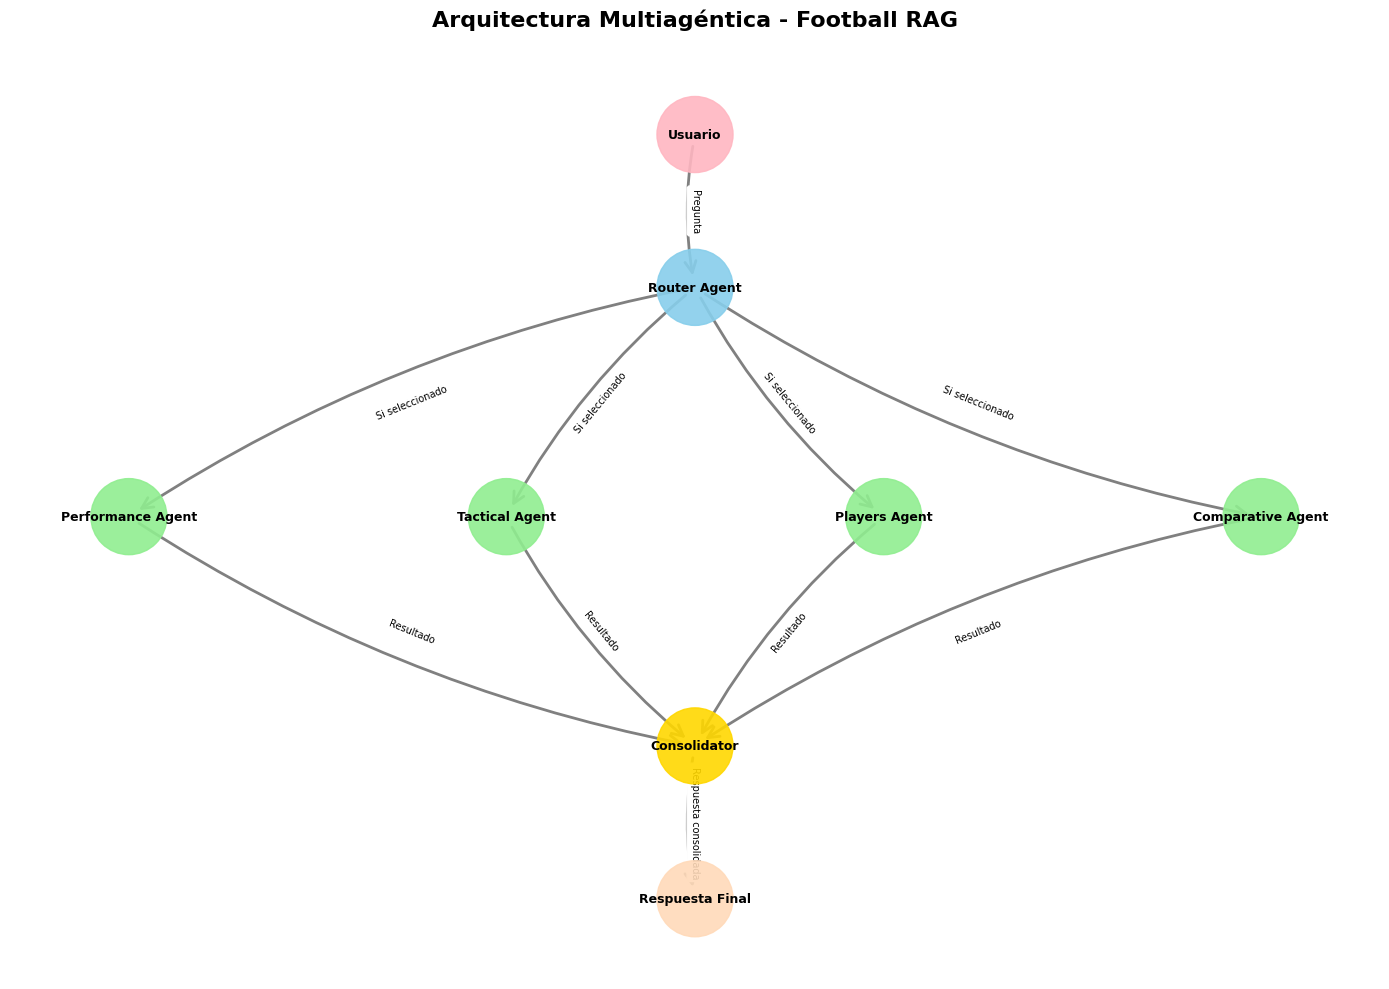

✅ Grafo visualizado correctamente


In [3]:
# Crear grafo dirigido
G = nx.DiGraph()

# Añadir nodos
nodos = {
    'user': 'Usuario',
    'router': 'Router Agent',
    'performance': 'Performance Agent',
    'tactical': 'Tactical Agent',
    'players': 'Players Agent',
    'comparative': 'Comparative Agent',
    'consolidator': 'Consolidator',
    'response': 'Respuesta Final'
}

for nodo_id, nodo_label in nodos.items():
    G.add_node(nodo_id, label=nodo_label)

# Añadir edges (conexiones)
edges = [
    ('user', 'router', 'Pregunta'),
    ('router', 'performance', 'Si seleccionado'),
    ('router', 'tactical', 'Si seleccionado'),
    ('router', 'players', 'Si seleccionado'),
    ('router', 'comparative', 'Si seleccionado'),
    ('performance', 'consolidator', 'Resultado'),
    ('tactical', 'consolidator', 'Resultado'),
    ('players', 'consolidator', 'Resultado'),
    ('comparative', 'consolidator', 'Resultado'),
    ('consolidator', 'response', 'Respuesta consolidada')
]

for source, target, label in edges:
    G.add_edge(source, target, label=label)

# Crear layout
pos = {
    'user': (0, 8),
    'router': (0, 6),
    'performance': (-3, 3),
    'tactical': (-1, 3),
    'players': (1, 3),
    'comparative': (3, 3),
    'consolidator': (0, 0),
    'response': (0, -2)
}

# Dibujar grafo
fig, ax = plt.subplots(figsize=(14, 10))
ax.set_title('Arquitectura Multiagéntica - Football RAG', fontsize=16, fontweight='bold', pad=20)

# Colores para diferentes tipos de nodos
color_map = []
for node in G.nodes():
    if node == 'user':
        color_map.append('#FFB6C1')  # Rosa para usuario
    elif node == 'router':
        color_map.append('#87CEEB')  # Azul para router
    elif node in ['performance', 'tactical', 'players', 'comparative']:
        color_map.append('#90EE90')  # Verde para agentes
    elif node == 'consolidator':
        color_map.append('#FFD700')  # Dorado para consolidador
    else:
        color_map.append('#FFDAB9')  # Melocotón para respuesta

# Dibujar nodos
nx.draw_networkx_nodes(G, pos, node_color=color_map, node_size=3000, 
                       node_shape='o', alpha=0.9, ax=ax)

# Dibujar edges
nx.draw_networkx_edges(G, pos, edge_color='gray', arrows=True, 
                       arrowsize=20, arrowstyle='->', width=2, 
                       connectionstyle='arc3,rad=0.1', ax=ax)

# Dibujar labels
labels = {node: nodos[node] for node in G.nodes()}
nx.draw_networkx_labels(G, pos, labels, font_size=9, font_weight='bold', ax=ax)

# Dibujar labels de edges
edge_labels = {(source, target): label for source, target, label in edges}
nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=7, ax=ax)

ax.axis('off')
plt.tight_layout()
plt.show()

print("✅ Grafo visualizado correctamente")

## 4. Visualizar las Bases de Conocimiento (ChromaDB)

El sistema tiene 3 colecciones en ChromaDB:

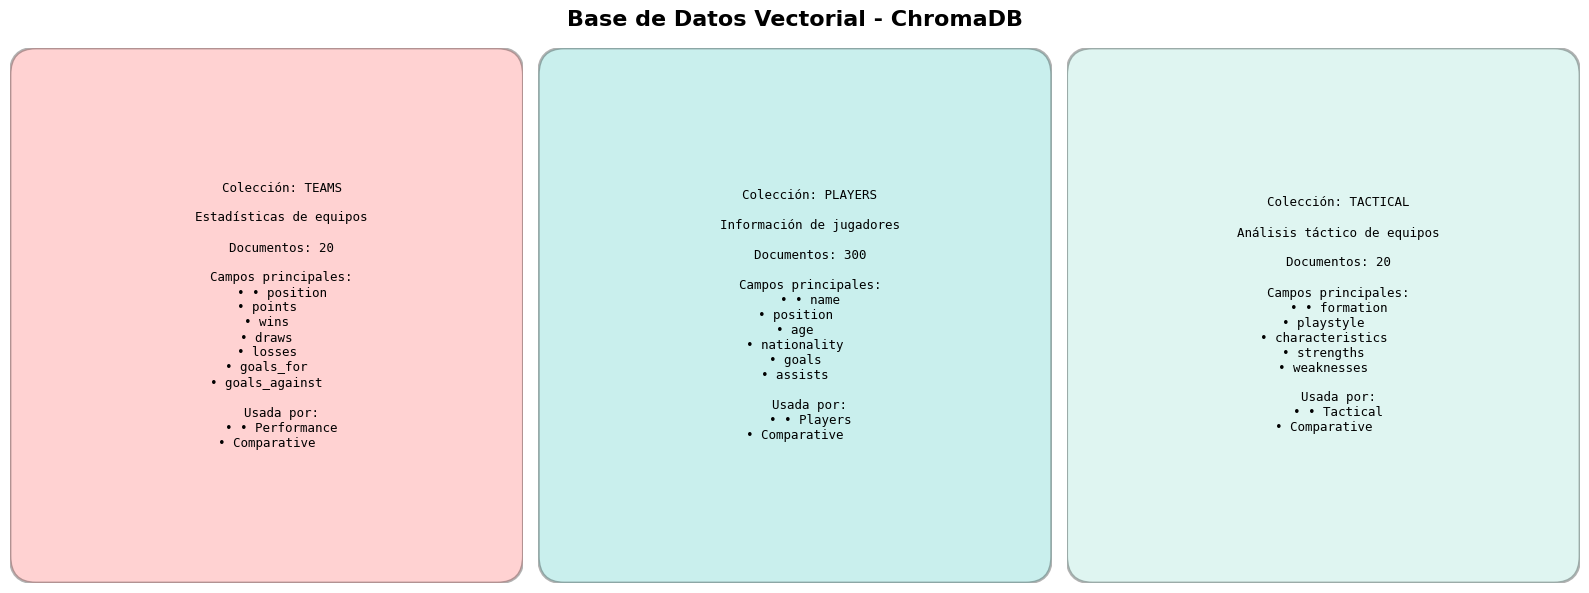

✅ Colecciones visualizadas


In [4]:
# Datos sobre las 3 colecciones
collections = {
    'teams': {
        'descripcion': 'Estadísticas de equipos',
        'documentos': 20,
        'campos': ['position', 'points', 'wins', 'draws', 'losses', 'goals_for', 'goals_against'],
        'agentes_usan': ['Performance', 'Comparative'],
        'color': '#FF6B6B'
    },
    'players': {
        'descripcion': 'Información de jugadores',
        'documentos': 300,
        'campos': ['name', 'position', 'age', 'nationality', 'goals', 'assists'],
        'agentes_usan': ['Players', 'Comparative'],
        'color': '#4ECDC4'
    },
    'tactical': {
        'descripcion': 'Análisis táctico de equipos',
        'documentos': 20,
        'campos': ['formation', 'playstyle', 'characteristics', 'strengths', 'weaknesses'],
        'agentes_usan': ['Tactical', 'Comparative'],
        'color': '#95E1D3'
    }
}

# Visualizar colecciones
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Base de Datos Vectorial - ChromaDB', fontsize=16, fontweight='bold')

for idx, (nombre, info) in enumerate(collections.items()):
    ax = axes[idx]
    
    # Crear texto
    texto = f"""
    Colección: {nombre.upper()}
    
    {info['descripcion']}
    
    Documentos: {info['documentos']}
    
    Campos principales:
    • {chr(10).join(['• ' + campo for campo in info['campos']])}
    
    Usada por:
    • {chr(10).join(['• ' + agente for agente in info['agentes_usan']])}
    """
    
    # Dibujar caja
    ax.add_patch(FancyBboxPatch((0.05, 0.05), 0.9, 0.9, 
                                boxstyle='round,pad=0.05', 
                                facecolor=info['color'], 
                                edgecolor='black', 
                                linewidth=2, 
                                alpha=0.3,
                                transform=ax.transAxes))
    
    ax.text(0.5, 0.5, texto, ha='center', va='center', 
           fontsize=9, family='monospace', transform=ax.transAxes)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')

plt.tight_layout()
plt.show()

print("✅ Colecciones visualizadas")

## 5. Visualizar un Ejemplo de Ejecución

Simulamos la ejecución para una pregunta real:

In [5]:
# Ejemplo de pregunta
pregunta = "¿Cómo juega tácticamente el Bayern Munich?"

# Simular flujo de ejecución
flujo_ejecucion = [
    {
        'paso': 1,
        'componente': 'Router Agent',
        'accion': 'Analiza pregunta',
        'entrada': pregunta,
        'salida': '{"agents": ["tactical"]}',
        'duracion': '~100ms'
    },
    {
        'paso': 2,
        'componente': 'Tactical Agent',
        'accion': 'Genera embedding',
        'entrada': pregunta,
        'salida': '[0.123, -0.456, 0.789, ...]',
        'duracion': '~50ms'
    },
    {
        'paso': 3,
        'componente': 'ChromaDB (tactical)',
        'accion': 'Busca vectores similares',
        'entrada': 'vector embedding',
        'salida': 'Bayern: 4-3-3, posesionista, ataque fluido...',
        'duracion': '~20ms'
    },
    {
        'paso': 4,
        'componente': 'GPT-4o-mini (LLM)',
        'accion': 'Genera respuesta',
        'entrada': 'Pregunta + contexto táctico',
        'salida': 'Análisis detallado del Bayern...',
        'duracion': '~500ms'
    },
    {
        'paso': 5,
        'componente': 'Consolidator',
        'accion': 'Devuelve respuesta',
        'entrada': 'Análisis de Tactical Agent',
        'salida': 'Respuesta final',
        'duracion': '~10ms'
    }
]

# Visualizar tabla de flujo
print(f"\n🔄 FLUJO DE EJECUCIÓN\n")
print(f"Pregunta: '{pregunta}'\n")
print("═" * 120)
print(f"{'Paso':<5} {'Componente':<20} {'Acción':<25} {'Entrada':<30} {'Salida (resumen)':<30} {'Duración':<10}")
print("═" * 120)

for item in flujo_ejecucion:
    print(f"{item['paso']:<5} {item['componente']:<20} {item['accion']:<25} {item['entrada'][:25]:<30} {item['salida'][:25]:<30} {item['duracion']:<10}")

print("═" * 120)
print(f"\nTiempo total aproximado: {sum([int(item['duracion'].split('~')[1].split('m')[0]) for item in flujo_ejecucion])}ms\n")


🔄 FLUJO DE EJECUCIÓN

Pregunta: '¿Cómo juega tácticamente el Bayern Munich?'

════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
Paso  Componente           Acción                    Entrada                        Salida (resumen)               Duración  
════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
1     Router Agent         Analiza pregunta          ¿Cómo juega tácticamente       {"agents": ["tactical"]}       ~100ms    
2     Tactical Agent       Genera embedding          ¿Cómo juega tácticamente       [0.123, -0.456, 0.789, ..      ~50ms     
3     ChromaDB (tactical)  Busca vectores similares  vector embedding               Bayern: 4-3-3, posesionis      ~20ms     
4     GPT-4o-mini (LLM)    Genera respuesta          Pregunta + contexto tácti      Análisis detallado del Ba      ~500ms    
5     Consolidator         Devuelve respuesta    

## 6. Visualizar Estadísticas de la Base de Conocimiento

C:\Users\ethan\AppData\Local\Temp\ipykernel_3320\3504225350.py:76: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
c:\Users\ethan\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


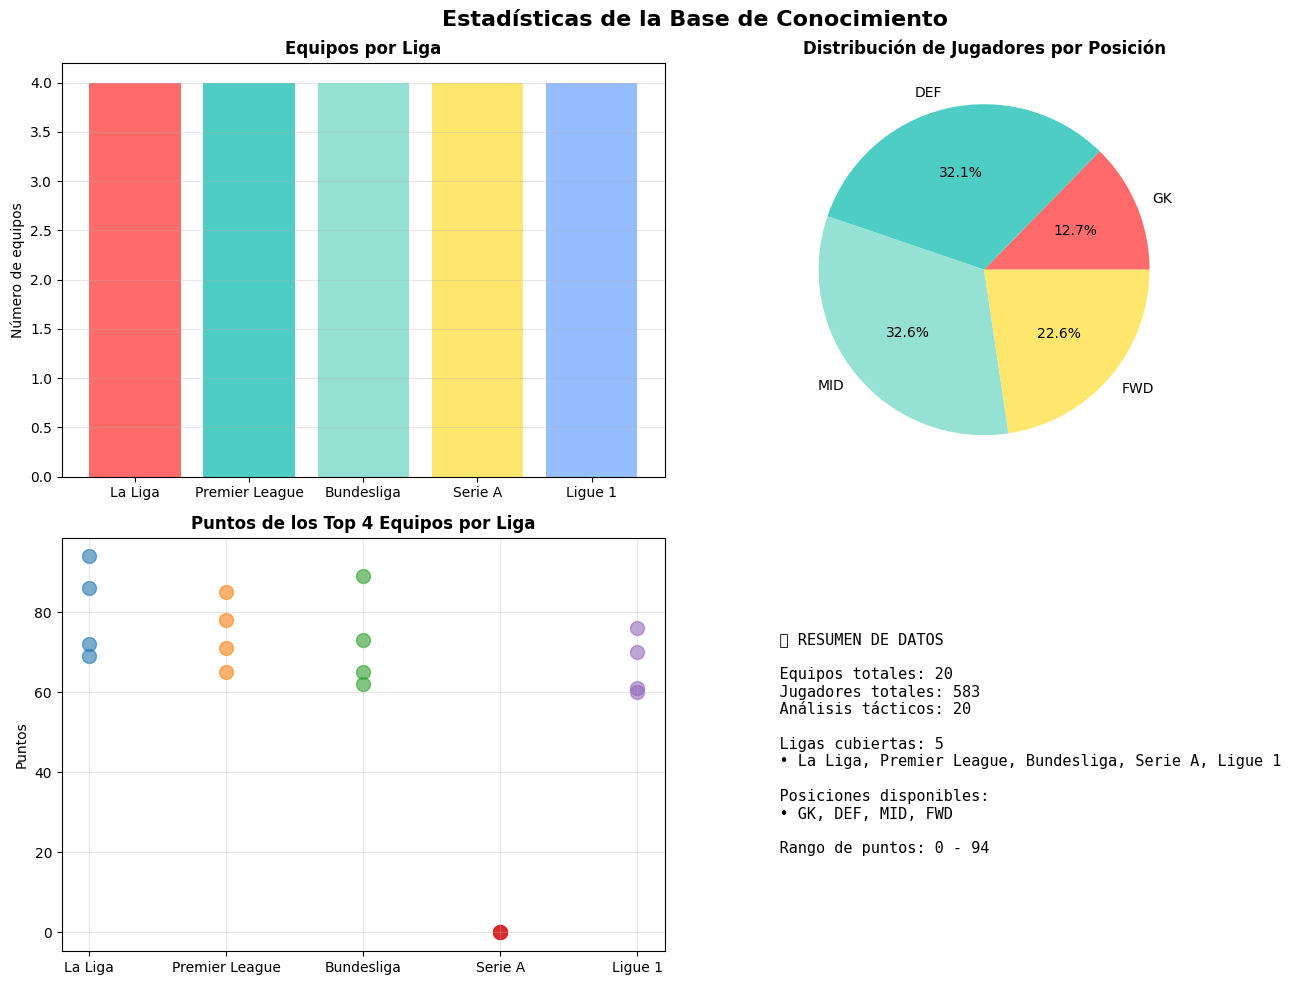

✅ Estadísticas cargadas y visualizadas


In [6]:
# Intentar cargar datos si existen
try:
    with open('../data/teams_data.json', 'r', encoding='utf-8') as f:
        teams_data = json.load(f)
    with open('../data/players_data.json', 'r', encoding='utf-8') as f:
        players_data = json.load(f)
    with open('../data/tactical_data.json', 'r', encoding='utf-8') as f:
        tactical_data = json.load(f)
    
    # Estadísticas
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Estadísticas de la Base de Conocimiento', fontsize=16, fontweight='bold')
    
    # 1. Equipos por liga
    ax1 = axes[0, 0]
    leagues = {}
    for team in teams_data.values():
        league = team.get('league')
        leagues[league] = leagues.get(league, 0) + 1
    
    ax1.bar(leagues.keys(), leagues.values(), color=['#FF6B6B', '#4ECDC4', '#95E1D3', '#FFE66D', '#95BDFF'])
    ax1.set_title('Equipos por Liga', fontweight='bold')
    ax1.set_ylabel('Número de equipos')
    ax1.grid(axis='y', alpha=0.3)
    
    # 2. Jugadores por posición
    ax2 = axes[0, 1]
    positions = {}
    for player in players_data:
        pos = player.get('position', 'N/A')
        positions[pos] = positions.get(pos, 0) + 1
    
    ax2.pie(positions.values(), labels=positions.keys(), autopct='%1.1f%%', 
           colors=['#FF6B6B', '#4ECDC4', '#95E1D3', '#FFE66D'])
    ax2.set_title('Distribución de Jugadores por Posición', fontweight='bold')
    
    # 3. Puntos por liga
    ax3 = axes[1, 0]
    league_points = {}
    for team in teams_data.values():
        league = team.get('league')
        if league not in league_points:
            league_points[league] = []
        league_points[league].append(team.get('points', 0))
    
    for league, points in league_points.items():
        ax3.scatter([league]*len(points), points, s=100, alpha=0.6, label=league)
    
    ax3.set_title('Puntos de los Top 4 Equipos por Liga', fontweight='bold')
    ax3.set_ylabel('Puntos')
    ax3.grid(True, alpha=0.3)
    
    # 4. Resumen
    ax4 = axes[1, 1]
    ax4.axis('off')
    
    resumen = f"""
    📊 RESUMEN DE DATOS
    
    Equipos totales: {len(teams_data)}
    Jugadores totales: {len(players_data)}
    Análisis tácticos: {len(tactical_data)}
    
    Ligas cubiertas: {len(leagues)}
    • {', '.join(leagues.keys())}
    
    Posiciones disponibles:
    • {', '.join(positions.keys())}
    
    Rango de puntos: {min([t['points'] for t in teams_data.values()])} - {max([t['points'] for t in teams_data.values()])}
    """
    
    ax4.text(0.1, 0.5, resumen, fontsize=11, family='monospace', 
            verticalalignment='center')
    
    plt.tight_layout()
    plt.show()
    
    print("✅ Estadísticas cargadas y visualizadas")
    
except FileNotFoundError:
    print("⚠️ Los archivos de datos no se encontraron.")
    print("Asegúrate de ejecutar primero:")
    print("  1. python fetch_football_data.py")
    print("  2. python embed_and_upload.py")

## 7. Resumen de la Arquitectura

El Football RAG Multiagent funciona mediante:

1. **Router Agent**: Entiende la intención de la pregunta y selecciona qué agentes activar
2. **Agentes Especializados**: Cada uno busca en su colección de ChromaDB
3. **ChromaDB**: Base de datos vectorial con 3 colecciones (teams, players, tactical)
4. **LLM (GPT-4o-mini)**: Genera respuestas coherentes basadas en el contexto recuperado
5. **Consolidator**: Une múltiples respuestas en una sola coherente

### Ventajas:
- ✅ Respuestas basadas en datos reales
- ✅ Arquitectura modular y escalable
- ✅ Búsqueda semántica inteligente
- ✅ Análisis especializado por dominio

### Flujo de tiempo:
- Procesamiento: ~700ms (incluyendo embedding + búsqueda + LLM)
- Datos: 20 equipos, 300+ jugadores, análisis tácticos